# Stratified Train/Val/Test Split

Produces `train.txt`, `val.txt`, and (optionally) `test.txt` with stratified sampling over pollen species.

In [1]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
DATASET_DIR   = "/storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/selection4class_training_27052024"
DATASET_NAME  = "selection4class_training_27052024"   # used in output paths
OUTPUT_DIR    = "/storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set"  # where txt files are written

TRAIN_RATIO   = 0.90
VAL_RATIO     = 0.10
TEST_RATIO    = 0.00   # set > 0 to produce test.txt

RANDOM_SEED   = 42
# ────────────────────────────────────────────────────────────────────────────

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Ratios must sum to 1.0"

In [2]:
import re
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
# ── Collect images and extract species labels ────────────────────────────────
PATTERN = re.compile(r'^\d{8}-\d+-(.+)-\d{8}-#\d+\.png$', re.IGNORECASE)

records = []
skipped = []

for fname in sorted(os.listdir(DATASET_DIR)):
    if not fname.lower().endswith('.png'):
        continue
    m = PATTERN.match(fname)
    if m:
        records.append({'filename': fname, 'species': m.group(1).lower()})
    else:
        skipped.append(fname)

df = pd.DataFrame(records)
print(f"Matched : {len(df):,} images")
print(f"Skipped : {len(skipped)} files (pattern mismatch)")
print(f"Classes : {df['species'].nunique()}")
if skipped:
    print("  Skipped examples:", skipped[:5])

Matched : 5,936 images
Skipped : 0 files (pattern mismatch)
Classes : 45


In [4]:
# ── Class distribution ───────────────────────────────────────────────────────
counts = df['species'].value_counts()
print(counts.to_string())
print(f"\nMax/min ratio: {counts.iloc[0] / counts.iloc[-1]:.1f}x")

species
plantago lanceolata        759
betula pendula             413
juniperus communis         382
fraxinus excelsior         316
potamogeton natans         306
peucedanum palustre        285
salix triandra             216
amaranthus sp.             188
betula nana                174
populus tremula            174
carex bigelowii            173
alnus incana               169
taraxacum officinale       166
frangula alnus             157
ranunculus acris           149
tilia platyphyllos         143
plantago media             142
potentilla anserina        140
picea abies                121
abies concolor             112
filipendula vulgaris       109
cardamine pratensis        109
helanthemum nummularium     82
ulmus minor                 78
artemisia campestris        78
humulus lupulus             78
triticum aestivum           73
rumex acetosella            72
pinus sylvestris            68
corylus avelllana           67
ledum palustre              48
calluna vulgaris            47


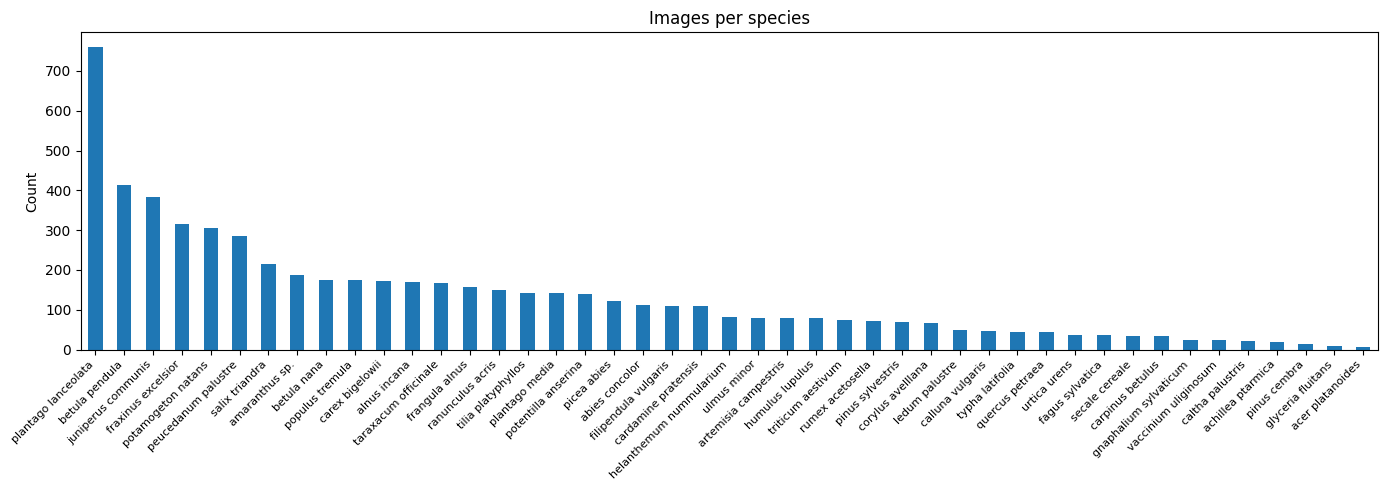

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
counts.plot(kind='bar', ax=ax)
ax.set_title("Images per species")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# ── Stratified split ─────────────────────────────────────────────────────────
# Classes with only 1 sample cannot be stratified — put them in train.
singleton_mask = df['species'].map(df['species'].value_counts() == 1)
df_single = df[singleton_mask].copy()
df_multi  = df[~singleton_mask].copy()

if len(df_single):
    print(f"Singletons (forced into train): {len(df_single)} images from classes:")
    print(df_single['species'].tolist())

if TEST_RATIO > 0:
    # First cut off test set, then split remainder into train/val
    trainval_ratio = TRAIN_RATIO + VAL_RATIO          # fraction of total to keep for train+val
    val_of_trainval = VAL_RATIO / trainval_ratio       # val fraction within the train+val pool

    df_trainval, df_test = train_test_split(
        df_multi,
        test_size=TEST_RATIO,
        stratify=df_multi['species'],
        random_state=RANDOM_SEED,
    )
    df_train, df_val = train_test_split(
        df_trainval,
        test_size=val_of_trainval,
        stratify=df_trainval['species'],
        random_state=RANDOM_SEED,
    )
else:
    df_test = pd.DataFrame(columns=df.columns)
    df_train, df_val = train_test_split(
        df_multi,
        test_size=VAL_RATIO,
        stratify=df_multi['species'],
        random_state=RANDOM_SEED,
    )

# Merge singletons into train
df_train = pd.concat([df_train, df_single], ignore_index=True)

print(f"\nSplit result:")
print(f"  train : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  val   : {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
if TEST_RATIO > 0:
    print(f"  test  : {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")
print(f"  total : {len(df_train)+len(df_val)+len(df_test):,}")


Split result:
  train : 5,342 (90.0%)
  val   : 594 (10.0%)
  total : 5,936


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [7]:
# ── Per-class split verification ─────────────────────────────────────────────
summary = pd.DataFrame({
    'total': df['species'].value_counts(),
    'train': df_train['species'].value_counts(),
    'val'  : df_val['species'].value_counts(),
}).fillna(0).astype(int)

if TEST_RATIO > 0:
    summary['test'] = df_test['species'].value_counts().reindex(summary.index).fillna(0).astype(int)

summary['train%'] = (summary['train'] / summary['total'] * 100).round(1)
summary['val%']   = (summary['val']   / summary['total'] * 100).round(1)
print(summary.sort_values('total', ascending=False).to_string())

                         total  train  val  train%  val%
species                                                 
plantago lanceolata        759    683   76    90.0  10.0
betula pendula             413    372   41    90.1   9.9
juniperus communis         382    344   38    90.1   9.9
fraxinus excelsior         316    284   32    89.9  10.1
potamogeton natans         306    275   31    89.9  10.1
peucedanum palustre        285    256   29    89.8  10.2
salix triandra             216    194   22    89.8  10.2
amaranthus sp.             188    169   19    89.9  10.1
betula nana                174    157   17    90.2   9.8
populus tremula            174    157   17    90.2   9.8
carex bigelowii            173    156   17    90.2   9.8
alnus incana               169    152   17    89.9  10.1
taraxacum officinale       166    149   17    89.8  10.2
frangula alnus             157    141   16    89.8  10.2
ranunculus acris           149    134   15    89.9  10.1
tilia platyphyllos         143 

In [8]:
# ── Write txt files ───────────────────────────────────────────────────────────
out = Path(OUTPUT_DIR)
out.mkdir(parents=True, exist_ok=True)

def write_split(df_split, name):
    if df_split.empty:
        return
    path = out / f"{name}.txt"
    lines = [f"./{DATASET_NAME}/{row.filename}\n" for row in df_split.itertuples()]
    with open(path, 'w') as f:
        f.writelines(lines)
    print(f"Wrote {len(lines):,} lines → {path}")

write_split(df_train, 'train')
write_split(df_val,   'val')
write_split(df_test,  'test')

Wrote 5,342 lines → /storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/train.txt
Wrote 594 lines → /storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/val.txt


In [9]:
# ── Quick sanity-check: peek at output files ──────────────────────────────────
for split in ['train', 'val', 'test']:
    p = out / f"{split}.txt"
    if p.exists():
        with open(p) as f:
            lines = f.readlines()
        print(f"{split}.txt  ({len(lines)} lines)  first entry: {lines[0].strip()}")

train.txt  (5342 lines)  first entry: ./selection4class_training_27052024/20190429-39-gnaphalium sylvaticum-20150922-#0156.png
val.txt  (594 lines)  first entry: ./selection4class_training_27052024/20190429-26-plantago lanceolata-20140627-#0415.png
